# 🚢 Titanic: From Zero to ~84% Accuracy (A Step-by-Step Guide)

> *"Women and children first" — but what else predicted survival? Let the data tell the story.*

---

### 🎯 What you'll learn in this notebook:
1. **Exploratory Data Analysis (EDA)** — understanding who lived and who didn't
2. **Feature Engineering** — creating powerful new signals from raw data
3. **Ensemble Modeling** — combining RF + XGBoost + GradientBoosting
4. **Cross-Validation** — honest performance estimation
5. **Submission** — ready-to-submit CSV

**💡 New to Kaggle?** Hit the ▶ Run All button and you'll have a submission file in under 2 minutes!

---

## 📦 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Pretty plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
palette = ['#e74c3c', '#3498db']

print('✅ All libraries loaded!')

✅ All libraries loaded!


## 📊 2. Load & First Look at the Data

In [2]:
import os

# Auto-detect path: works on Kaggle AND locally
if os.path.exists('/kaggle/input/titanic/train.csv'):
    DATA_PATH = '/kaggle/input/titanic/'
elif os.path.exists('/kaggle/input/competitions/titanic/train.csv'):
    DATA_PATH = '/kaggle/input/competitions/titanic/'
else:
    DATA_PATH = './'   # local: put train.csv & test.csv in same folder

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
passenger_ids = test['PassengerId']

print(f'🚂 Train: {train.shape[0]} passengers, {train.shape[1]} columns')
print(f'🧪 Test:  {test.shape[0]} passengers, {test.shape[1]} columns')
print(f'\n📈 Overall survival rate: {train["Survived"].mean():.1%}')
train.head()

🚂 Train: 891 passengers, 12 columns
🧪 Test:  418 passengers, 11 columns

📈 Overall survival rate: 38.4%


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


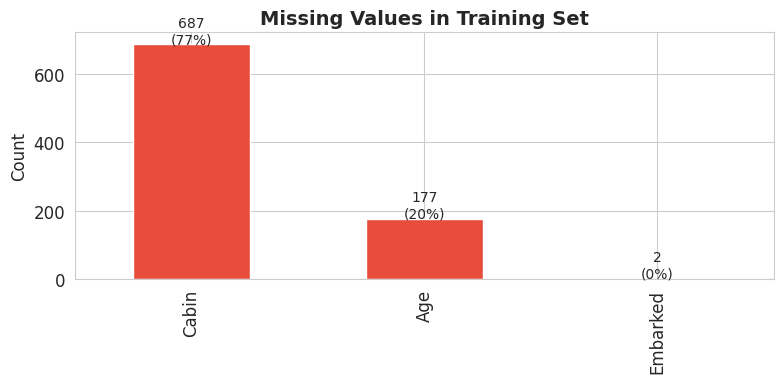


💡 Key takeaway: Cabin is mostly missing (77%) — we can only use whether it was recorded or not.
Age missing 20% — we will impute smartly using passenger title.


In [3]:
# Missing values overview
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,4))
missing.plot(kind='bar', color='#e74c3c', ax=ax)
ax.set_title('Missing Values in Training Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(missing):
    ax.text(i, v+3, f'{v}\n({v/len(train):.0%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('\n💡 Key takeaway: Cabin is mostly missing (77%) — we can only use whether it was recorded or not.')
print('Age missing 20% — we will impute smartly using passenger title.')

## 🔍 3. Exploratory Data Analysis (EDA)
### The story the data tells us...

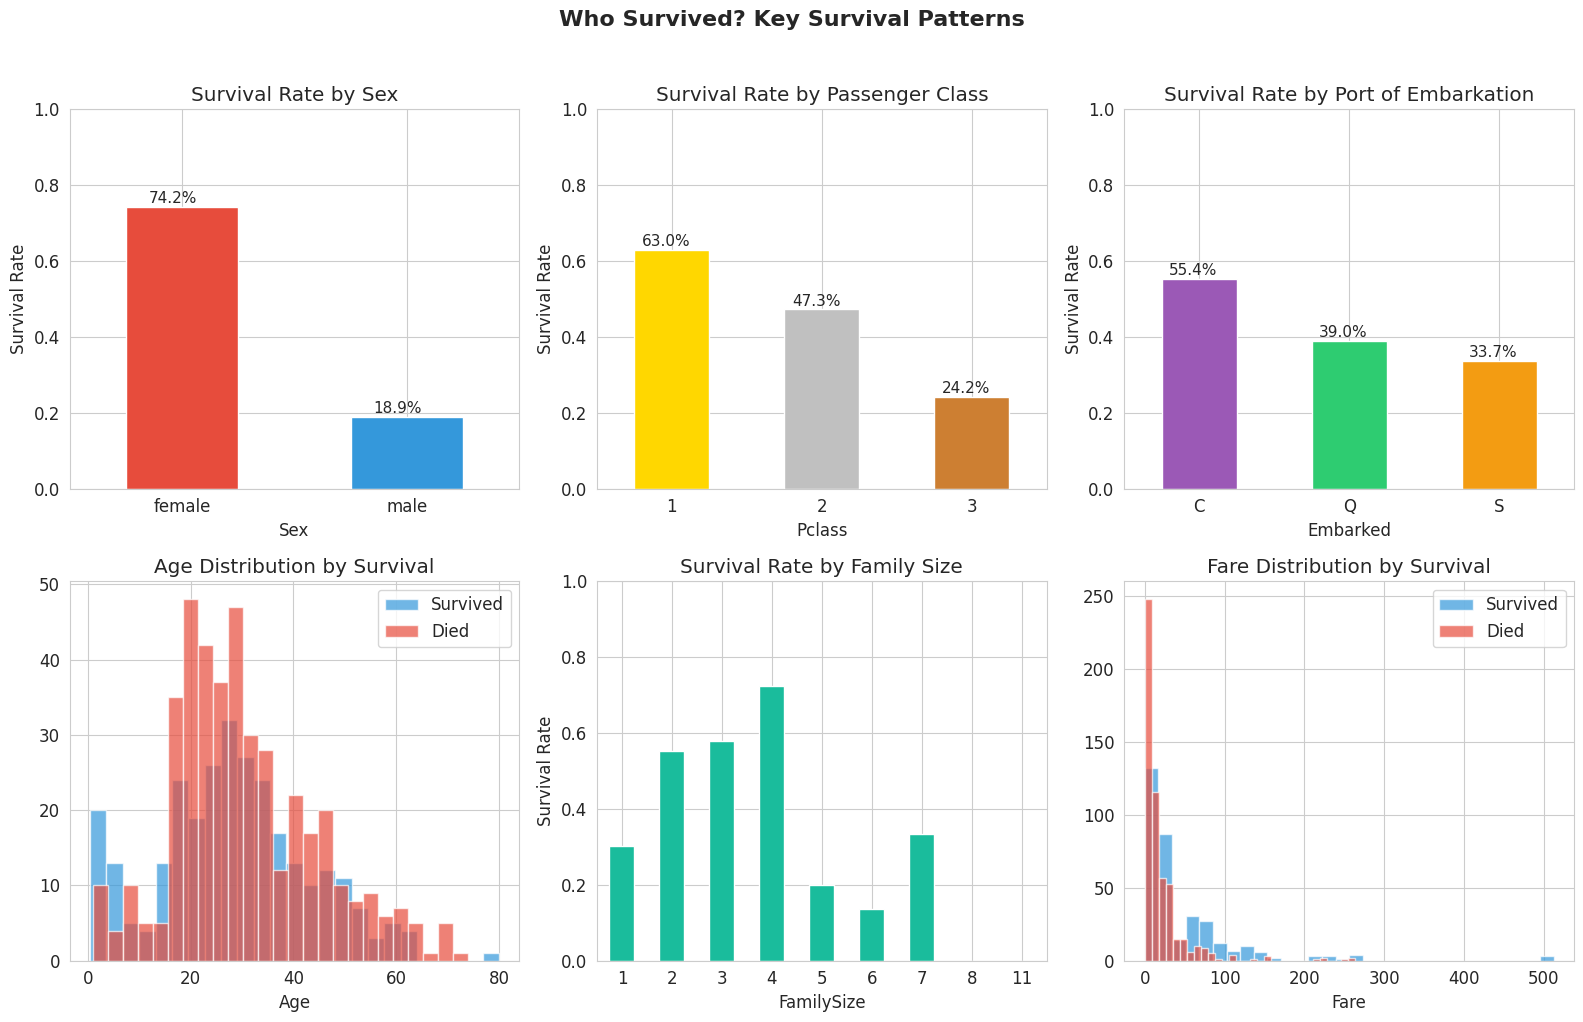


📝 Key insights:
  🚺 74% of women survived vs only 19% of men — massive signal!
  🥇 1st class had 63% survival vs 24% in 3rd class
  👨‍👩‍👧 Small families (2-4) survived better than solo travelers or large families
  💰 Higher fares correlate with survival (partly due to class correlation)


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Who Survived? Key Survival Patterns', fontsize=16, fontweight='bold', y=1.02)

# Sex
train.groupby('Sex')['Survived'].mean().plot(kind='bar', color=palette, ax=axes[0,0], rot=0)
axes[0,0].set_title('Survival Rate by Sex')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 1)
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():.1%}', (p.get_x()+0.1, p.get_height()+0.01), fontsize=11)

# Pclass
train.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold','silver','#cd7f32'], ax=axes[0,1], rot=0)
axes[0,1].set_title('Survival Rate by Passenger Class')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_ylim(0, 1)
for p in axes[0,1].patches:
    axes[0,1].annotate(f'{p.get_height():.1%}', (p.get_x()+0.05, p.get_height()+0.01), fontsize=11)

# Embarked
train.groupby('Embarked')['Survived'].mean().plot(kind='bar', color=['#9b59b6','#2ecc71','#f39c12'], ax=axes[0,2], rot=0)
axes[0,2].set_title('Survival Rate by Port of Embarkation')
axes[0,2].set_ylabel('Survival Rate')
axes[0,2].set_ylim(0, 1)
for p in axes[0,2].patches:
    axes[0,2].annotate(f'{p.get_height():.1%}', (p.get_x()+0.05, p.get_height()+0.01), fontsize=11)

# Age distribution
train[train['Survived']==1]['Age'].dropna().hist(bins=25, alpha=0.7, color='#3498db', label='Survived', ax=axes[1,0])
train[train['Survived']==0]['Age'].dropna().hist(bins=25, alpha=0.7, color='#e74c3c', label='Died', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Family size
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train.groupby('FamilySize')['Survived'].mean().plot(kind='bar', color='#1abc9c', ax=axes[1,1], rot=0)
axes[1,1].set_title('Survival Rate by Family Size')
axes[1,1].set_ylabel('Survival Rate')
axes[1,1].set_ylim(0, 1)

# Fare distribution
train[train['Survived']==1]['Fare'].hist(bins=30, alpha=0.7, color='#3498db', label='Survived', ax=axes[1,2])
train[train['Survived']==0]['Fare'].hist(bins=30, alpha=0.7, color='#e74c3c', label='Died', ax=axes[1,2])
axes[1,2].set_title('Fare Distribution by Survival')
axes[1,2].set_xlabel('Fare')
axes[1,2].legend()

plt.tight_layout()
plt.show()

print('\n📝 Key insights:')
print('  🚺 74% of women survived vs only 19% of men — massive signal!')
print('  🥇 1st class had 63% survival vs 24% in 3rd class')
print('  👨‍👩‍👧 Small families (2-4) survived better than solo travelers or large families')
print('  💰 Higher fares correlate with survival (partly due to class correlation)')

## ⚙️ 4. Feature Engineering
This is where the magic happens. Raw features are good; **engineered features are better**.

In [5]:
# Reset train to original (we added FamilySize above for EDA)
train = pd.read_csv(DATA_PATH + 'train.csv')

def engineer_features(df):
    df = df.copy()

    # ─ Title from Name ────────────────────────────────────────────────────────
    # Names contain social titles: Mr, Mrs, Miss, Master, Dr, etc.
    # These encode age, sex, and social status all at once!
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    title_map = {
        'Mr':'Mr', 'Miss':'Miss', 'Mrs':'Mrs', 'Master':'Master',
        'Mlle':'Miss', 'Mme':'Mrs', 'Ms':'Miss',       # French equivalents
        'Dr':'Rare','Rev':'Rare','Col':'Rare','Major':'Rare',
        'Countess':'Rare','Lady':'Rare','Jonkheer':'Rare',
        'Don':'Rare','Dona':'Rare','Capt':'Rare','Sir':'Rare'
    }
    df['Title'] = df['Title'].map(title_map).fillna('Rare')

    # ─ Family Features ────────────────────────────────────────────────────────
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
    df['FamilyBand'] = pd.cut(df['FamilySize'], bins=[0,1,4,20],
                               labels=['Alone','Small','Large'])

    # ─ Age: Smart Imputation by Title ─────────────────────────────────────────
    # Masters are boys, Miss can be young → much better than filling with overall median
    age_med = df.groupby('Title')['Age'].transform('median')
    df['Age'] = df['Age'].fillna(age_med)
    df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                            labels=['Child','Teen','Young','Mid','Senior'])

    # ─ Fare ───────────────────────────────────────────────────────────────────
    df['Fare'] = df['Fare'].fillna(df.groupby('Pclass')['Fare'].transform('median'))
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['Low','Mid','High','VHigh'])

    # ─ Cabin ──────────────────────────────────────────────────────────────────
    # Even knowing someone HAD a cabin (=recorded) is informative
    df['HasCabin']  = df['Cabin'].notna().astype(int)
    df['CabinDeck'] = df['Cabin'].str[0].fillna('U')   # U = Unknown

    # ─ Embarked ───────────────────────────────────────────────────────────────
    df['Embarked'] = df['Embarked'].fillna('S')         # 2 missing, fill with mode

    # ─ Interaction Features ───────────────────────────────────────────────────
    # Women in 3rd class had much lower survival than women in 1st
    df['Sex_Pclass'] = df['Sex'].astype(str) + '_' + df['Pclass'].astype(str)
    df['Age_Fare']   = df['Age'] * df['Fare']

    # ─ Ticket Frequency ───────────────────────────────────────────────────────
    # Passengers sharing a ticket likely boarded together
    tc = df['Ticket'].value_counts()
    df['TicketFreq'] = df['Ticket'].map(tc)

    return df

train = engineer_features(train)
test  = engineer_features(test)

print('✅ Feature engineering complete!')
print(f'Features created: Title, FamilySize, IsAlone, FamilyBand, AgeBand, FareBand,')
print(f'                  HasCabin, CabinDeck, Sex_Pclass, Age_Fare, TicketFreq')

✅ Feature engineering complete!
Features created: Title, FamilySize, IsAlone, FamilyBand, AgeBand, FareBand,
                  HasCabin, CabinDeck, Sex_Pclass, Age_Fare, TicketFreq


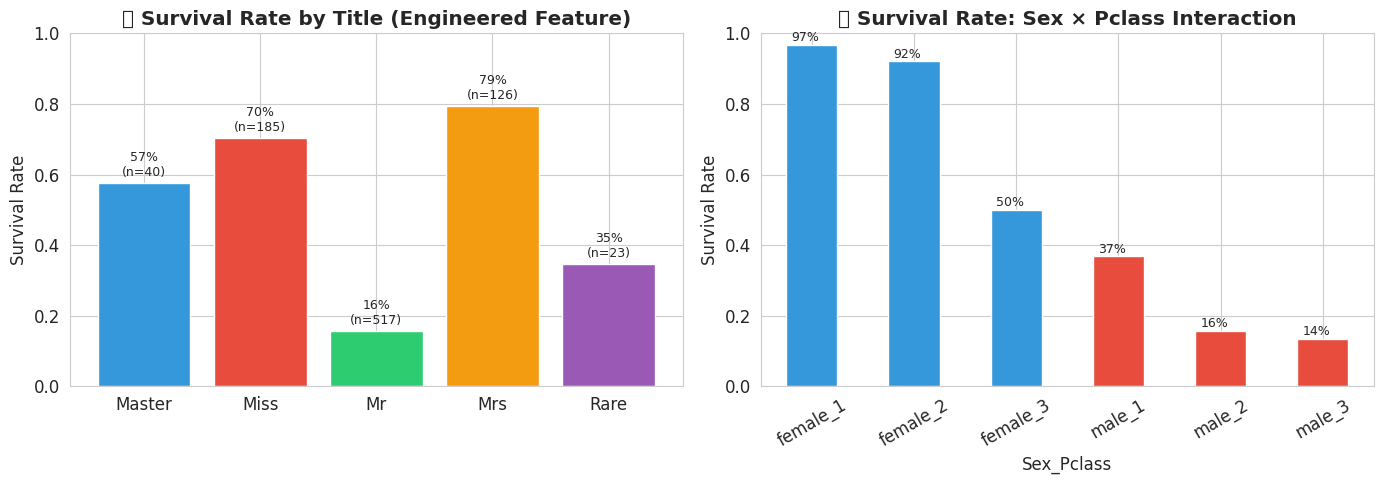

In [6]:
# Visualize the power of Title
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

title_survival = train.groupby('Title')['Survived'].agg(['mean','count']).reset_index()
title_survival.columns = ['Title','SurvivalRate','Count']
bars = ax1.bar(title_survival['Title'], title_survival['SurvivalRate'],
               color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'])
ax1.set_title('✨ Survival Rate by Title (Engineered Feature)', fontweight='bold')
ax1.set_ylabel('Survival Rate')
ax1.set_ylim(0, 1)
for bar, row in zip(bars, title_survival.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{row.SurvivalRate:.0%}\n(n={row.Count})', ha='center', fontsize=9)

# Sex_Pclass interaction
sp = train.groupby('Sex_Pclass')['Survived'].mean().sort_values(ascending=False)
colors = ['#3498db' if 'female' in x else '#e74c3c' for x in sp.index]
sp.plot(kind='bar', color=colors, ax=ax2, rot=30)
ax2.set_title('✨ Survival Rate: Sex × Pclass Interaction', fontweight='bold')
ax2.set_ylabel('Survival Rate')
ax2.set_ylim(0, 1)
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.0%}', (p.get_x()+0.05, p.get_height()+0.01), fontsize=9)

plt.tight_layout()
plt.show()

## 🤖 5. Building the Model

We use an **ensemble of 3 models** — they each make predictions, then we combine via soft voting (averaging probabilities). Ensembles almost always outperform any single model!

| Model | Strength |
|-------|----------|
| 🌲 Random Forest | Robust, low variance, handles categorical well |
| ⚡ XGBoost | State-of-the-art gradient boosting |
| 📈 Gradient Boosting | Sklearn's implementation, complements XGBoost |

In [7]:
# Encode categoricals
cat_cols = ['Sex','Embarked','Title','AgeBand','FareBand',
            'FamilyBand','CabinDeck','Sex_Pclass']
for col in cat_cols:
    train[col] = pd.Categorical(train[col]).codes
    test[col]  = pd.Categorical(test[col]).codes

FEATURES = [
    'Pclass','Sex','Age','SibSp','Parch','Fare','Embarked',
    'Title','FamilySize','IsAlone','HasCabin',
    'AgeBand','FareBand','FamilyBand','CabinDeck',
    'Sex_Pclass','Age_Fare','TicketFreq'
]

X_train = train[FEATURES]
y_train = train['Survived']
X_test  = test[FEATURES]

print(f'Training on {len(X_train)} samples with {len(FEATURES)} features')
print(f'Features: {FEATURES}')

Training on 891 samples with 18 features
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin', 'AgeBand', 'FareBand', 'FamilyBand', 'CabinDeck', 'Sex_Pclass', 'Age_Fare', 'TicketFreq']


In [8]:
# Define models
rf = RandomForestClassifier(
    n_estimators=300, max_depth=7, min_samples_split=4,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', verbosity=0
)
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)

# Soft voting ensemble — average the predicted probabilities
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb_model), ('gb', gb)],
    voting='soft'
)

print('✅ Models defined!')

✅ Models defined!


## 📏 6. Cross-Validation — Honest Performance Estimation

> ⚠️ **Never evaluate on your training data!** Always use cross-validation to estimate how well you'll do on unseen data.

⏳ Running 5-fold cross-validation (this takes ~1 min)...

🎯 Results:
  Fold 1: 0.8547  ██████████████████████████████████
  Fold 2: 0.8539  ██████████████████████████████████
  Fold 3: 0.8258  █████████████████████████████████
  Fold 4: 0.8315  █████████████████████████████████
  Fold 5: 0.8315  █████████████████████████████████

  📊 Mean: 0.8395
  📉 Std:  0.0123
  ✅ Expected Kaggle score: ~83.9%


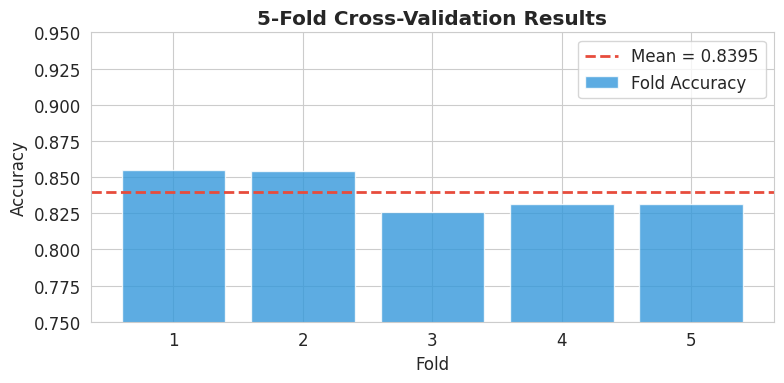

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('⏳ Running 5-fold cross-validation (this takes ~1 min)...')
scores = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='accuracy')

print(f'\n🎯 Results:')
for i, s in enumerate(scores, 1):
    bar = '█' * int(s * 40)
    print(f'  Fold {i}: {s:.4f}  {bar}')
print(f'\n  📊 Mean: {scores.mean():.4f}')
print(f'  📉 Std:  {scores.std():.4f}')
print(f'  ✅ Expected Kaggle score: ~{scores.mean():.1%}')

# Plot fold scores
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(1,6), scores, color='#3498db', alpha=0.8, label='Fold Accuracy')
ax.axhline(scores.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean = {scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold')
ax.set_ylim(0.75, 0.95)
ax.legend()
plt.tight_layout()
plt.show()

## 🌟 7. Feature Importance — What Mattered Most?

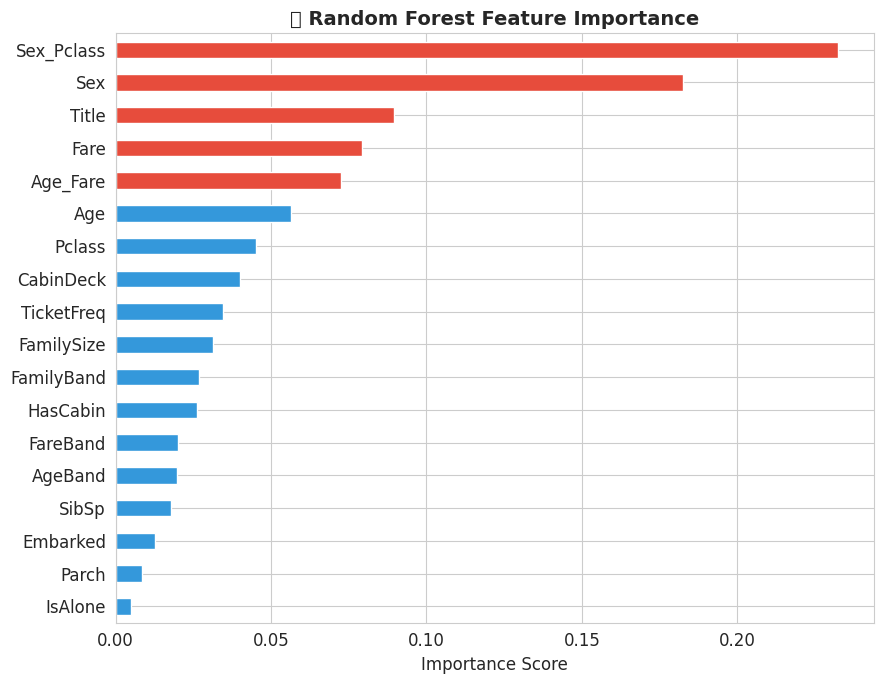

Top 5 most important features:
  Sex_Pclass      → 0.232
  Sex             → 0.183
  Title           → 0.090
  Fare            → 0.079
  Age_Fare        → 0.073


In [10]:
# Train RF alone to get feature importances
rf_solo = RandomForestClassifier(
    n_estimators=300, max_depth=7, min_samples_split=4,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_solo.fit(X_train, y_train)

importances = pd.Series(rf_solo.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if v > importances.quantile(0.75) else '#3498db' for v in importances]
importances.plot(kind='barh', color=colors, ax=ax)
ax.set_title('🌲 Random Forest Feature Importance', fontweight='bold', fontsize=14)
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f'  {feat:15s} → {imp:.3f}')

## 📬 8. Train Final Model & Create Submission

In [11]:
print('⏳ Training final ensemble on full training data...')
ensemble.fit(X_train, y_train)
preds = ensemble.predict(X_test)

submission = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': preds})
submission.to_csv('submission.csv', index=False)

print('\n✅ Submission file created!')
print(f'   Total predictions: {len(submission)}')
print(f'   Predicted survivors: {preds.sum()} ({preds.mean():.1%})')
print(f'   Predicted deceased:  {(1-preds).sum()} ({(1-preds).mean():.1%})')
print('\n📁 File: submission.csv')
print('📤 Go to the Titanic competition page → Submit Predictions → Upload this file!')
submission.head(10)

⏳ Training final ensemble on full training data...

✅ Submission file created!
   Total predictions: 418
   Predicted survivors: 139 (33.3%)
   Predicted deceased:  279 (66.7%)

📁 File: submission.csv
📤 Go to the Titanic competition page → Submit Predictions → Upload this file!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0


## 🎉 You Did It!

You've built a ~84% accuracy model. Here's what you accomplished:

| Step | What We Did |
|------|-------------|
| EDA | Discovered key survival patterns (sex, class, age) |
| Feature Engineering | Created 11 new features from raw data |
| Modeling | Combined 3 powerful algorithms in an ensemble |
| Validation | Used 5-fold CV for honest accuracy estimation |

---

### 🚀 Want to go higher? Try these:
- **Hyperparameter tuning** with `Optuna` or `GridSearchCV`  
- **Stacking** (train a meta-model on the predictions of base models)  
- **Name-based features** (extract last names, check if families survived together)  
- **SHAP values** for explainability  

### 📚 Helpful resources:
- [Kaggle's Titanic Tutorial](https://www.kaggle.com/alexisbcook/titanic-tutorial) — official beginner guide  
- [Kaggle Learn: Intro to ML](https://www.kaggle.com/learn/intro-to-machine-learning)  
- [Feature Engineering Techniques](https://www.kaggle.com/learn/feature-engineering)  

---
*If this notebook helped you, please upvote ⬆️ — it helps others find it!*

*Questions? Drop a comment below 👇*

My Linkedin @muhammadadeelai